In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pypff
from scipy.ndimage import median_filter
import pandas as pd
from tqdm import tqdm

In [2]:
def _build_disk_kernel(R, N, AA=4):
    """
    Erzeuge einen 'Top-Hat'-Apertur-Kernel in Subpixel-Einheiten mit
    Anti-Aliasing (AAxAA Supersampling pro Subpixel-Zelle).
    Kernel-Gewichte sind bereits durch (N*N) geteilt, wie im C++-Code.
    """
    size = 2*R + 1
    K = np.zeros((size, size), dtype=np.float64)
    # Zell-Mitten sind auf ganzzahligen Koordinaten; jede Zelle hat Kantenlänge 1
    # AA-Samples gleichmäßig in der Zelle verteilen
    offs = (np.arange(AA) + 0.5) / AA - 0.5  # zentrierte Offsets in [-0.5, 0.5)
    grid = np.stack(np.meshgrid(offs, offs, indexing='xy'), axis=-1).reshape(-1, 2)

    for iu, u in enumerate(range(-R, R+1)):
        for iv, v in enumerate(range(-R, R+1)):
            # Zelle mit Zentrum (u, v); disk Zentrum bei (0,0), Radius R
            # approximierte Flächenüberlappung via Samples in der Zelle
            pts = grid + np.array([u, v])
            inside = (pts[:, 0]**2 + pts[:, 1]**2) <= (R**2)
            frac = inside.mean()  # Anteil der Zellenfläche innerhalb der Apertur
            K[iu, iv] = frac / (N * N)
    return K

def _conv2_validpad(img, kernel):
    """
    Einfache 2D-Faltung (same) mit Null-Padding. img, kernel sind 2D numpy arrays.
    Für kleine Kernel (R<=~8) performt das ausreichend gut.
    """
    H, W = img.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    pad = np.pad(img, ((ph, ph), (pw, pw)), mode='constant', constant_values=0.0)
    out = np.zeros_like(img, dtype=np.float64)
    # naive Schleifen-Faltung über Kernel (klein), aber Vektorisierung über Bildzeilen
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * pad[i:i+H, j:j+W]
    return out

def clean_image_1d(
    pixel_values_1d: np.ndarray,
    side: int | None = None,
    *,
    # Geometrie / Auflösung
    N: int = 5,                           # Subpixel pro Pixel (N×N)
    aperture_radius_deg: float = 0.12,    # nur informativ; für R wird standardmäßig ein fester Wert genutzt
    pixel_width_deg: float | None = None, # falls gesetzt, wird R aus Winkeln bestimmt (empfohlen)
    subpixel_radius_scale_deg: float | None = None,  # alternative direkte Winkel-zu-R Umrechnung
    # Rauschmodell & Schwelle
    NSB: float = 1.0,           # mittlere NSB-Zählung (gleiche Einheiten wie Pixelwerte)
    readout_noise: float = 10., # σ_readout
    SNR: float = 7.0,           # benötigte Signifikanz
    # Disk-Kernel
    R_override: int | None = None,  # direkt Radius in Subpixeln setzen (überschreibt alles oben)
    AA: int = 4                     # Anti-Aliasing für Kernel (4–8 sinnvoll)
) -> np.ndarray:
    """
    Implementiert das Aperture-Cleaning aus deinem C++-Code.
    Eingabe: 1D-Array der Pixelwerte, quadratische Kamera.
    Ausgabe: gereinigtes 1D-Array in gleicher Form.

    Hinweise:
    - Standardmäßig: N=5, R≈2 (wie im C++-Snippet). Für exakte Geometrie gib pixel_width_deg an.
    - NSB & readout_noise müssen in denselben Einheiten wie die Pixelwerte sein.
    """
    # --- Bildform herstellen (quadratisch) ---
    vals = np.asarray(pixel_values_1d)
    if side is None:
        side = int(round(np.sqrt(vals.size)))
        if side * side != vals.size:
            raise ValueError("Bild ist nicht quadratisch – bitte 'side' angeben.")
    img = vals.reshape(side, side).astype(np.float64, copy=False)
    binsX = binsY = side

    # --- Subpixel-Raster erzeugen (dividedImage) ---
    # jedes Pixel -> N×N identische Subpixel
    onesNN = np.ones((N, N), dtype=img.dtype)
    div = np.kron(img, onesNN)  # Shape: (binsX*N, binsY*N)

    # --- Radius R in Subpixel-Einheiten bestimmen ---
    if R_override is not None:
        R = int(R_override)
    else:
        if subpixel_radius_scale_deg is not None:
            # entspricht C++: R = aperture_radius_deg / (subpixel_radius_scale_deg)
            R = int(np.rint(aperture_radius_deg / subpixel_radius_scale_deg))
        elif pixel_width_deg is not None:
            # Subpixelwinkel = pixel_width_deg / N
            R = int(np.rint(aperture_radius_deg * N / pixel_width_deg))
        else:
            # Defaults analog C++-Beispiel (0.12°/0.06° ≈ 2)
            R = 2
    R = max(1, R)

    # --- Apertur-Kernel bauen (mit AA-Übersampling an den Rändern) ---
    K = _build_disk_kernel(R, N, AA=AA)

    # --- Apertur-Mittelung (Signal) & Gewichtssumme (für Randverluste) ---
    sig_map = _conv2_validpad(div, K)                # gewichtete Mittelung (wie binSizeAvg)
    weight_sum = _conv2_validpad(np.ones_like(div), K)  # Summe der w pro Subpixel

    # --- Rauschschwelle σ_map (wie imageThreshold) ---
    var_const = readout_noise**2 + NSB
    thr_map = np.sqrt(np.clip(weight_sum, 0.0, None) * var_const)

    # --- Pixelweise Entscheidung: hat irgendein Subpixel SNR überschritten? ---
    keep = np.zeros((binsX, binsY), dtype=bool)
    for i in range(binsX):
        for j in range(binsY):
            # Subpixel-Block für diesen Pixel
            sl_i = slice(i*N, (i+1)*N)
            sl_j = slice(j*N, (j+1)*N)
            # true, wenn eines der Subpixel den Cut schafft
            block_ok = np.any(sig_map[sl_i, sl_j] > SNR * thr_map[sl_i, sl_j])
            keep[i, j] = block_ok

    # --- Ergebnisbild aufbauen: verwerfe nicht gehaltene Pixel ---
    new_img = img.copy()
    new_img[~keep] = 0.0

    # --- negative Pixel entfernen ---
    new_img[new_img < 0.0] = 0.0

    # --- isolierte Pixel (8er-Nachbarschaft) entfernen ---
    # Prüfe, ob ein gesetzter Pixel mind. einen gesetzten Nachbarn (8-neighb.) hat
    nz = new_img != 0.0
    if nz.any():
        # Faltung mit 3x3-Einsen (ohne Zentrum) zur Nachbarschaftszählung
        neigh = (
            np.pad(nz, 1, constant_values=False)[0:-2, 0:-2] +
            np.pad(nz, 1, constant_values=False)[0:-2, 1:-1] +
            np.pad(nz, 1, constant_values=False)[0:-2, 2:  ] +
            np.pad(nz, 1, constant_values=False)[1:-1, 0:-2] +
            np.pad(nz, 1, constant_values=False)[1:-1, 2:  ] +
            np.pad(nz, 1, constant_values=False)[2:  , 0:-2] +
            np.pad(nz, 1, constant_values=False)[2:  , 1:-1] +
            np.pad(nz, 1, constant_values=False)[2:  , 2:  ]
        )
        isolated = (nz & (neigh == 0))
        new_img[isolated] = 0.0

    # --- Bild verwerfen, falls weniger als 3 Pixel ---
    if np.count_nonzero(new_img) < 3:
        new_img[:] = 0.0

    return new_img.reshape(-1)

def estimate_global_nsb_noise(vals_1d):
    med = np.median(vals_1d)
    mad = np.median(np.abs(vals_1d - med))
    sigma = 1.4826 * mad
    return med, sigma

def estimate_global_quantile(vals_1d, q=0.4):
    nsb = np.quantile(vals_1d, q)
    # Noise über MAD um dieses Quantil (robust)
    mad = np.median(np.abs(vals_1d - nsb))
    sigma = 1.4826 * mad
    return nsb, sigma

def estimate_global_nsb_noise_clipped(vals_1d, max_iter=3, sigma_clip=3.0):
    x = vals_1d.astype(float)
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        med = np.median(x[mask])
        mad = np.median(np.abs(x[mask] - med))
        sigma = 1.4826 * mad
        new_mask = np.abs(x - med) < sigma_clip * sigma
        if new_mask.sum() == mask.sum():  # konvergiert
            break
        mask = new_mask
    # finale Schätzung
    med = np.median(x[mask])
    mad = np.median(np.abs(x[mask] - med))
    sigma = 1.4826 * mad
    return med, sigma

def conservative_from_iqr(vals_1d, q_nsb=0.75):
    x = np.asarray(vals_1d, float)
    # konservativer NSB = oberes Quantil (z.B. 75%)
    NSB_eff = float(np.quantile(x, q_nsb))
    # robuste σ-Schätzung über IQR: σ ≈ IQR / 1.349
    q75, q25 = np.quantile(x, [0.75, 0.25])
    sigma_eff = float((q75 - q25) / 1.349)
    return NSB_eff, sigma_eff

def conservative_nsb_sigma_from_single_frame(vals_1d, side, win=7, q=0.80):
    """Ein Frame -> ein globaler NSB (konservativ) + ein globales σ (konservativ)."""
    img = vals_1d.reshape(side, side).astype(float)

    # Lokaler Hintergrund (Median) als NSB-Schätzung pro Pixel
    nsb_loc = median_filter(img, size=win)

    # Lokale robuste Streuung (MAD -> σ) pro Pixel
    resid = img - nsb_loc
    mad_loc = median_filter(np.abs(resid), size=win)
    sigma_loc = 1.4826 * mad_loc

    # Konservativ: nimm hohes Quantil über die Kamera, z.B. 80. Perzentil
    NSB_eff = float(np.quantile(nsb_loc, q))
    sigma_eff = float(np.quantile(sigma_loc, q))
    return NSB_eff, sigma_eff

def clipped_global(vals_1d, clip_sigma=3.0, max_iter=3, winsor=0.98):
    x = np.asarray(vals_1d, float)
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        med = np.median(x[mask])
        mad = np.median(np.abs(x[mask] - med))
        sig = 1.4826 * mad
        new_mask = np.abs(x - med) < clip_sigma * sig
        if new_mask.sum() == mask.sum(): break
        mask = new_mask
    # Winsorize die verbleibenden 2% Spitzen
    lo, hi = np.quantile(x[mask], [1-winsor, winsor])
    xw = x.clip(lo, hi)
    NSB_eff = float(np.median(xw))
    # robuste σ via IQR
    q75, q25 = np.quantile(xw, [0.75, 0.25])
    sigma_eff = float((q75 - q25) / 1.349)
    return NSB_eff, sigma_eff

def conservative_single_frame_params(vals_1d, side, win=7,
                                     q_nsb=0.95, q_sigma=0.95):
    img = vals_1d.reshape(side, side).astype(float)
    nsb_loc = median_filter(img, size=win)             # lokaler Hintergrund
    resid   = img - nsb_loc
    mad_loc = median_filter(np.abs(resid), size=win)   # lokale MAD
    sigma_loc = 1.4826 * mad_loc                       # lokale σ-Schätzung
    NSB_eff   = float(np.quantile(nsb_loc, q_nsb))
    sigma_eff = float(np.quantile(sigma_loc, q_sigma))
    return NSB_eff, sigma_eff

def estimate_nsb_noise_no_prior(vals_1d, side=None, win=7, q_nsb=0.95, q_sigma=0.95):
    vals = np.asarray(vals_1d, float)
    if side is None:
        side = int(round(np.sqrt(vals.size)))
        if side*side != vals.size:
            raise ValueError("side angeben (Bild ist nicht quadratisch).")
    img = vals.reshape(side, side)

    # 1) Lokaler Hintergrund via Medianfilter
    nsb_loc = median_filter(img, size=win)

    # 2) Lokale robuste Streuung aus Residuen
    resid = img - nsb_loc
    mad_loc = median_filter(np.abs(resid), size=win)
    sigma_loc = 1.4826 * mad_loc

    # 3) Konservative globale Ein-Werte
    NSB_eff   = float(np.quantile(nsb_loc, q_nsb))
    noise_eff = float(np.quantile(sigma_loc, q_sigma))
    return NSB_eff, noise_eff

In [4]:
rng = np.random.default_rng(0)
side = 32
vals = rng.poisson(0.5, side*side).astype(float)

# kleiner "Schauer"-Fleck mit Peak ~15
cx, cy = 16, 20
for dx in range(-2, 3):
    for dy in range(-2, 3):
        if 0 <= cx+dx < side and 0 <= cy+dy < side:
            vals[(cy+dy)*side + (cx+dx)] += 15 - 3*(abs(dx)+abs(dy))

cleaned = clean_image_1d(
    vals,
    side=side,
    N=5,
    pixel_width_deg=0.31,      # damit wird R ≈ round(0.12*5/0.31)=2
    NSB=0.5,                   # mittlere Untergrundrate (gleiche Einheiten wie vals)
    readout_noise=0.5,         # σ_readout in denselben Einheiten
    SNR=5.0,                   # moderater Cut
    AA=4
)


In [14]:
#file="start_2025-10-18T07-28-39Z.dp_ph1024.bpp_2.module_254.seqno_0.pff"
#pff = pypff.io.datapff(file)
#data, metadata = pff.readpff(metadata=True)
data=np.load("crab_2025-10-20_data.npy")
i=10
side=32
NSB=estimate_global_nsb_noise(data[i])
print(NSB)
data_cleaned=np.zeros((len(data),1024))
for i in tqdm(range(len(data))):
    NSB=estimate_global_nsb_noise(data[i])
    #NSB=estimate_nsb_noise_no_prior(data[i])
    data_cleaned[i] = clean_image_1d(
        data[i],
        side=side,
        N=5,
        pixel_width_deg=0.31,      # damit wird R ≈ round(0.12*5/0.31)=2
        NSB=1,                   # mittlere Untergrundrate (gleiche Einheiten wie vals)
        readout_noise=10,         # σ_readout in denselben Einheiten
        SNR=7.0,                   # moderater Cut
        AA=4
    )

(np.float64(11.0), np.float64(7.412999999999999))


100%|█████████████████████████████████████████████████████████████████████████████| 16186/16186 [03:08<00:00, 85.82it/s]


In [15]:
timestamps=np.load("crab_2025-10-20_timestamp.npy")
data_cleaned_cut=data_cleaned[np.sum(data_cleaned,axis=1)!=0]
timestamps_cleaned_cut=timestamps[np.sum(data_cleaned,axis=1)!=0]
print(len(data_cleaned),len(data_cleaned_cut))
print(len(timestamps),len(timestamps_cleaned_cut))
np.save("crab_2025-10-20_data_cleaned_SNR7",data_cleaned_cut)
np.save("crab_2025-10-20_timestamp_cleaned_SNR7",timestamps_cleaned_cut)

16186 6920
16186 6920


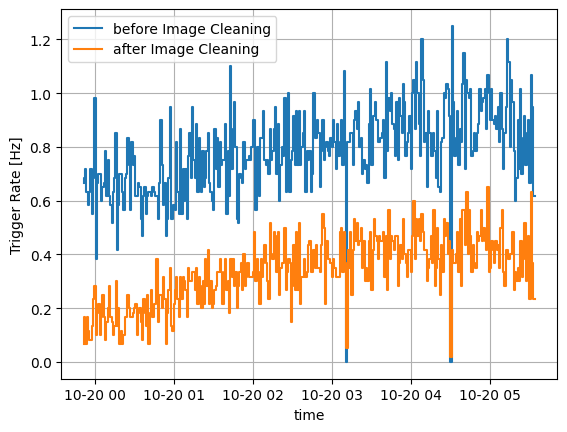

In [16]:
bin_width = 60
bins = np.arange(timestamps.min(), timestamps.max() + bin_width, bin_width)
counts, _ = np.histogram(timestamps, bins=bins)
rate = counts / bin_width  # Hz
bin_centers = bins[:-1] + bin_width/2
df = pd.DataFrame({'timestamp': bin_centers, 'rate': rate})
df["time"] = pd.to_datetime(bin_centers, unit='s', utc=True).tz_convert('America/Los_Angeles')
plt.step(df["time"],df["rate"],label="before Image Cleaning")
timestamps=timestamps_cleaned_cut
bin_width = 60
bins = np.arange(timestamps.min(), timestamps.max() + bin_width, bin_width)
counts, _ = np.histogram(timestamps, bins=bins)
rate = counts / bin_width  # Hz
bin_centers = bins[:-1] + bin_width/2
df = pd.DataFrame({'timestamp': bin_centers, 'rate': rate})
df["time"] = pd.to_datetime(bin_centers, unit='s', utc=True).tz_convert('America/Los_Angeles')
plt.step(df["time"],df["rate"],label="after Image Cleaning")
plt.grid()
plt.xlabel("time")
plt.ylabel("Trigger Rate [Hz]")
plt.legend()
plt.savefig("crab_2025-10-20_trigger_SNR7.png",dpi=300)
#plt.ylim(0,2)

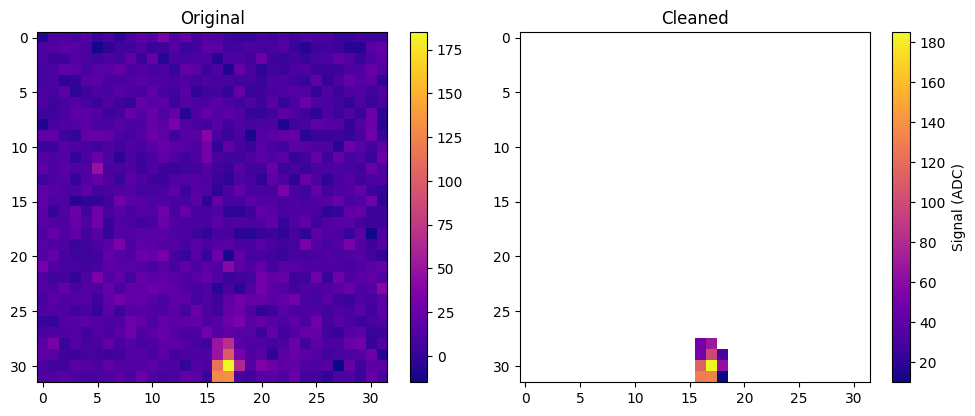

In [32]:
data=np.load("crab_2025-10-19_data.npy")
i=8
side=32
NSB=estimate_global_nsb_noise(data[i])
#NSB=estimate_nsb_noise_no_prior(data[i],q_nsb=0.80, q_sigma=0.80)
#print(NSB)
cleaned = clean_image_1d(
        data[i],
        side=side,
        N=5,
        pixel_width_deg=0.31,      # damit wird R ≈ round(0.12*5/0.31)=2
        NSB=NSB[0],                   # mittlere Untergrundrate (gleiche Einheiten wie vals)
        readout_noise=NSB[1],         # σ_readout in denselben Einheiten
        SNR=5.0,                   # moderater Cut
        AA=4
    )
matrix = data[i].reshape((32, 32))
im_matrix = matrix
matrix2 = cleaned.reshape((32, 32))
masked = np.ma.masked_where(matrix2 == 0, matrix2)

# Copy the plasma colormap and set masked color to white
cmap = plt.cm.plasma.copy()
cmap.set_bad(color='white')

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left subplot – original
im1 = axes[0].imshow(im_matrix, cmap='plasma', interpolation='nearest')
axes[0].set_title('Original')
fig.colorbar(im1, ax=axes[0])

# Right subplot – masked version
im2 = axes[1].imshow(masked, cmap=cmap, interpolation='nearest')
axes[1].set_title('Cleaned')
fig.colorbar(im2, ax=axes[1], label='Signal (ADC)')

# Improve layout
plt.tight_layout()
plt.show()

In [33]:
NSB

(np.float64(11.0), np.float64(7.412999999999999))